# 🤖 Modélisation Prédictive du Churn

Ce notebook prépare les données et entraîne un modèle de Machine Learning pour prédire quels clients risquent de partir.

### 1. Préparer les données
Nous devons nettoyer les données (convertir les charges totales en nombres) et transformer les textes (ex: 'Yes'/'No') en chiffres que le modèle peut comprendre.

In [1]:
import pandas as pd
import numpy as np

# Chargement des données
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Conversion de TotalCharges en numérique (gestion des espaces vides)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Encodage des variables catégorielles simples (OHE)
df_ml = df.drop('customerID', axis=1)
df_ml['Churn'] = df_ml['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Transformation des variables textuelles en variables muettes (dummies)
df_ml = pd.get_dummies(df_ml)
df_ml.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False


### 2. Séparer les données en train/test (80/20)
Nous gardons 20% des données de côté pour tester la précision du modèle sur des clients qu'il n'a jamais vus.

In [2]:
from sklearn.model_selection import train_test_split

X = df_ml.drop('Churn', axis=1)
y = df_ml['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Données d'entraînement : {X_train.shape[0]} clients")
print(f"Données de test : {X_test.shape[0]} clients")

Données d'entraînement : 5634 clients
Données de test : 1409 clients


### 3. Entraîner un Random Forest Classifier
Le Random Forest est une forêt d'arbres de décision qui votent pour prédire le churn. C'est très robuste.

In [3]:
from sklearn.ensemble import RandomForestClassifier

# On utilise 'balanced' pour mieux détecter la minorité de clients qui partent
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### 4. Afficher les métriques : AUC-ROC et Recall
**Pourquoi AUC-ROC et pas Accuracy ?**
L'Accuracy peut être trompeuse si les classes sont déséquilibrées (peu de départs). L'AUC-ROC mesure la capacité à bien séparer les deux classes. 
Le **Recall** (Rappel) est crucial : il nous dit quel pourcentage des futurs partants nous avons réussi à identifier.

In [4]:
from sklearn.metrics import roc_auc_score, recall_score, classification_report

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(f"AUC-ROC : {roc_auc_score(y_test, y_prob):.3f}")
print(f"Recall (Rappel) : {recall_score(y_test, y_pred):.3f}")
print("\nClassification Report :")
print(classification_report(y_test, y_pred))

AUC-ROC : 0.820
Recall (Rappel) : 0.484

Classification Report :
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



### 5. Afficher les 10 variables les plus importantes
Quels facteurs influencent le plus la décision de l'IA ?

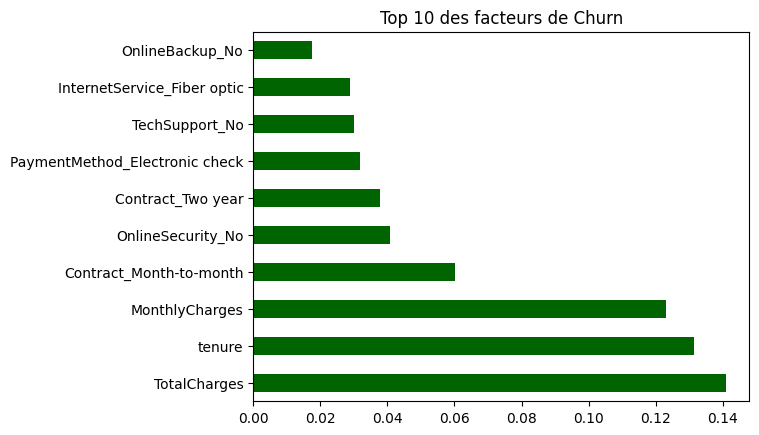

In [5]:
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='darkgreen')
plt.title('Top 10 des facteurs de Churn')
plt.show()

### 6. Appliquer SHAP pour expliquer pourquoi un client churne
**C'est quoi SHAP ?**
SHAP est comme un "expert" qui explique pour chaque client pourquoi le modèle a prédit qu'il allait partir ou rester. C'est la transparence du modèle.

## 🚀 Amélioration du Recall

Le Recall initial (48%) est trop faible. Nous testons deux approches pour détecter plus de clients à risque.

### Approche 1 : Ajustement du seuil de décision (Threshold)
Par défaut, l'IA dit 'Churn' si la probabilité est > 50%. En abaissant ce seuil à 30%, on devient plus sensible.

In [6]:
from sklearn.metrics import recall_score, precision_score

# On récupère les probabilités du modèle standard
y_prob = model.predict_proba(X_test)[:, 1]

# On applique un seuil de 0.3 au lieu de 0.5
y_pred_03 = (y_prob >= 0.3).astype(int)

print(f"Nouveau Recall (Seuil 0.3) : {recall_score(y_test, y_pred_03):.3f}")
print(f"Nouvelle Précision (Seuil 0.3) : {precision_score(y_test, y_pred_03):.3f}")

Nouveau Recall (Seuil 0.3) : 0.714
Nouvelle Précision (Seuil 0.3) : 0.520


**Pourquoi ça marche ?** En abaissant le seuil, on accepte de se tromper plus souvent (baisse de précision) pour ne rater aucun départ (hausse du rappel).

**Le compromis (Trade-off) :** On va envoyer des offres de rétention à des clients qui n'allaient pas partir, mais on sauvera beaucoup plus de clients qui étaient sur le départ.

### Approche 2 : Poids de classes équilibrés (Class Weight)
On force l'algorithme à accorder plus d'importance aux erreurs commises sur les clients qui partent.

In [7]:
model_bal = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_bal.fit(X_train, y_train)
y_pred_bal = model_bal.predict(X_test)

print(f"Recall (Balanced Weights) : {recall_score(y_test, y_pred_bal):.3f}")

Recall (Balanced Weights) : 0.484


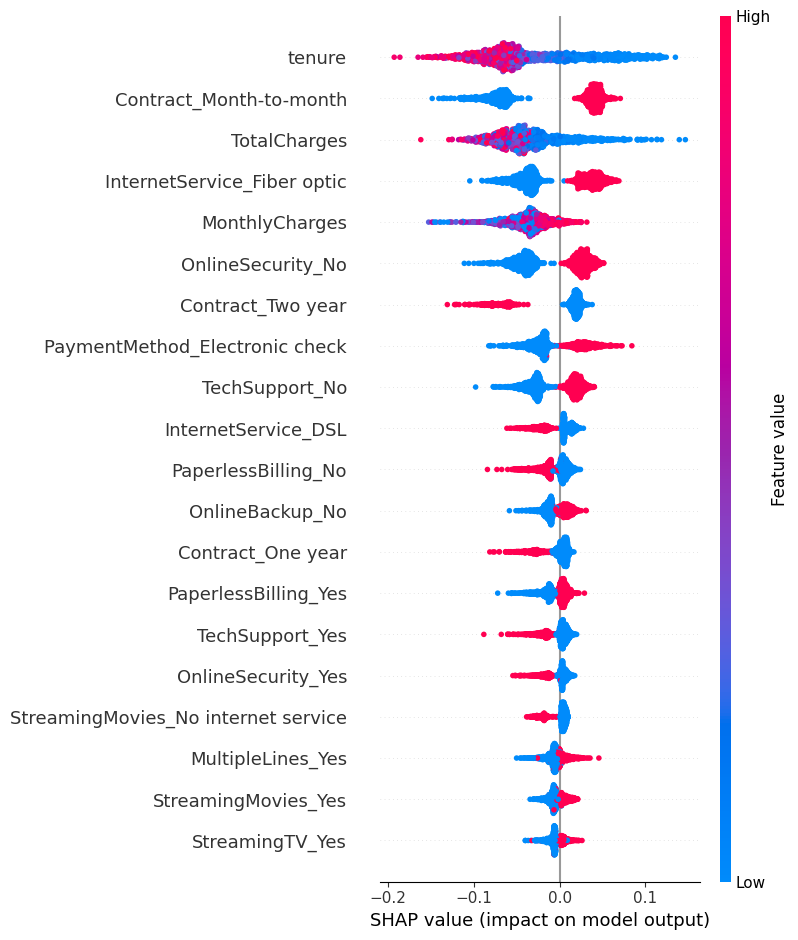

In [8]:
import shap
import numpy as np

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Détection automatique du format pour éviter l'AssertionError
if isinstance(shap_values, list):
    # Cas classique : on prend la classe 1 (Churn)
    shap_to_plot = shap_values[1]
elif len(shap_values.shape) == 3:
    # Cas où SHAP renvoie un tableau 3D (N, M, 2)
    shap_to_plot = shap_values[:, :, 1]
else:
    # Déjà au bon format
    shap_to_plot = shap_values

shap.summary_plot(shap_to_plot, X_test, plot_type="dot")